# Daily Occupancy Forecasting & Demand Dynamics Modeling
#### Notebook 3: Operational Calibration and Reliability Tuning

This notebook calibrates the operational decision layer developed in Notebook 2.

The goal is not to retrain the forecasting models, but to improve how their outputs are translated into business actions.

In particular, this notebook tests:

- whether recent realized model performance can be used as a reliability signal
- whether stronger directional probabilities should lead to stronger actions
- whether instability and recent reliability should both affect operational confidence

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import mean_absolute_error

from forecast_utils import (
    add_features,
    add_direction_target,
    apply_spike_labels,
    compute_spike_threshold,
    split_train_test_pre_2019_with_seasonality,
    load_trained_artifacts,
    apply_saved_seasonality,
    build_guardrail_from_saved_thresholds
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)

### 1. Load saved artifacts and rebuild the test period

The models were already trained in Notebook 2 and saved to disk.

Here they are loaded again so that the same forecasts, directional probabilities, and guardrail logic can be reconstructed for calibration.

In [22]:
daily = pd.read_csv("daily_cleaned_dataset.csv", parse_dates=["Date"])

artifacts = load_trained_artifacts("models")

point_models = artifacts["point_models"]
direction_models = artifacts["direction_models"]
metadata = artifacts["metadata"]

features_t1 = metadata["features_t1"]
features_medium = metadata["features_medium"]
direction_feature_map = metadata["direction_feature_map"]
spike_threshold = metadata["spike_threshold"]
booking_guardrail_threshold = metadata["booking_guardrail_threshold"]
notice_guardrail_threshold = metadata["notice_guardrail_threshold"]
seasonal_by_day_train = metadata["seasonal_by_day_train"]
direction_threshold = metadata["direction_threshold"]

print("Loaded artifacts successfully.")
print("Point models:", list(point_models.keys()))
print("Direction models:", list(direction_models.keys()))

Loaded artifacts successfully.
Point models: ['t1', 't7', 't14', 't21', 't28']
Direction models: ['t1', 't7', 't14', 't21', 't28']


### 2. Rebuild predictions and directional outputs

This step recreates the point forecasts and directional probabilities on the test set.

The goal is to rebuild a consistent test dataset for calibration.

In [23]:
daily = add_features(daily)
daily_model = daily.dropna().copy()
daily_model["naive_delta"] = 0.0

# same split
train, test = split_train_test_pre_2019_with_seasonality(daily_model)

# same direction labels
for horizon, target_col in [
    ("t1", "target_t1"),
    ("t7", "target_t7"),
    ("t14", "target_t14"),
    ("t21", "target_t21"),
    ("t28", "target_t28")
]:
    train = add_direction_target(
        train,
        target_col=target_col,
        new_col=f"Direction_{horizon}",
        threshold=0.005
    )
    test = add_direction_target(
        test,
        target_col=target_col,
        new_col=f"Direction_{horizon}",
        threshold=0.005
    )

# same spike labels
train = apply_spike_labels(train, spike_threshold)
test = apply_spike_labels(test, spike_threshold)

# same guardrail logic from saved thresholds
guardrail_test = build_guardrail_from_saved_thresholds(
    test,
    booking_threshold=booking_guardrail_threshold,
    notice_threshold=notice_guardrail_threshold
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Guardrail counts:")
print(guardrail_test.value_counts())

Train shape: (855, 60)
Test shape: (336, 60)
Guardrail counts:
0    258
1     78
Name: count, dtype: int64


### 3. Build matured correctness signals

A prediction can only be used for reliability tracking once its outcome is known.

For that reason, this notebook builds matured correctness measures:

- T+1 correctness becomes known one day later
- T+7 correctness becomes known seven days later

These matured signals are then used to estimate whether the model is currently tracking reality well.


In [24]:
# Reset index to ensure clean, sequential ordering of the test dataset
# (important for later operations like shifting and rolling windows)
test = test.copy().reset_index(drop=True)

# Attach the guardrail flag (0 = stable, 1 = unstable)
# This marks periods where the system is under pressure and predictions are less reliable
test["Guardrail"] = np.array(guardrail_test)

# Generate point forecasts using the saved models from Notebook 02
# Each prediction represents expected occupancy at a future horizon
test["Pred_t1"] = point_models["t1"].predict(test[features_t1])         # 1-day ahead forecast
test["Pred_t7"] = point_models["t7"].predict(test[features_medium])
test["Pred_t14"] = point_models["t14"].predict(test[features_medium])
test["Pred_t21"] = point_models["t21"].predict(test[features_medium])
test["Pred_t28"] = point_models["t28"].predict(test[features_medium])   # 28-day ahead forecast

# Quick inspection: compare current occupancy, actual future values, and predictions
# This helps verify that predictions align correctly with their corresponding targets
print(test[[
    "Date", "Occupancy",
    "target_t1", "Pred_t1",
    "target_t7", "Pred_t7",
    "target_t14", "Pred_t14",
    "target_t21", "Pred_t21",
    "target_t28", "Pred_t28"
]].head())

        Date  Occupancy  target_t1   Pred_t1  target_t7   Pred_t7  target_t14  Pred_t14  target_t21  Pred_t21  target_t28  Pred_t28
0 2019-01-01   0.557625   0.569490  0.554446   0.622225  0.582151      0.7500  0.672171      0.7125  0.757092      0.6875  0.799845
1 2019-01-02   0.569490   0.569490  0.566464   0.658123  0.593610      0.7625  0.678047      0.7000  0.759999      0.6625  0.797874
2 2019-01-03   0.569490   0.557625  0.565522   0.682055  0.552710      0.7500  0.622583      0.7000  0.694791      0.6750  0.742977
3 2019-01-04   0.557625   0.581354  0.552976   0.694021  0.566460      0.7750  0.639264      0.7000  0.707912      0.6625  0.755500
4 2019-01-05   0.581354   0.605083  0.578161   0.705987  0.579341      0.7500  0.635755      0.6750  0.702259      0.7000  0.765704


#### 3.1 Safe probability extraction

In [25]:
def extract_up_down_proba(model, X):
    # Get class probabilities from the trained classifier; 
    # output shape: (n_samples, n_classes)
    proba = model.predict_proba(X)
    
    # Map each class label (-1, 0, 1) to its column index in the probability array
    # This ensures we extract the correct probabilities regardless of class order
    class_to_idx = {cls: i for i, cls in enumerate(model.classes_)}

    # Safety check: ensure both DOWN (-1) and UP (+1) classes exist
    if -1 not in class_to_idx or 1 not in class_to_idx:
        raise ValueError("Directional model must contain both classes -1 and 1.")

    # Extract column indices for DOWN and UP probabilities
    down_idx = class_to_idx[-1]
    up_idx = class_to_idx[1]

    # Return separate arrays for DOWN and UP probabilities
    return proba[:, down_idx], proba[:, up_idx]


# Generate directional probabilities for each forecast horizon
for h in ["t1", "t7", "t14", "t21", "t28"]:
    
    # Use short-term features for T+1, medium-term features for longer horizons
    feats = features_t1 if h == "t1" else features_medium
    
    # Extract probability of DOWN and UP from the trained classifier
    prob_down, prob_up = extract_up_down_proba(direction_models[h], test[feats])

    # Store probabilities in the dataset for later use (strength, actions, calibration)
    test[f"Prob_Down_{h}"] = prob_down
    test[f"Prob_Up_{h}"] = prob_up

    # Convert probabilities into a directional prediction:
    # +1 → UP if probability exceeds threshold
    # -1 → DOWN if probability exceeds threshold
    #  0 → UNCERTAIN if neither is strong enough
    test[f"Direction_Pred_{h}"] = np.where(
        test[f"Prob_Up_{h}"] >= direction_threshold, 1,
        np.where(test[f"Prob_Down_{h}"] >= direction_threshold, -1, 0)
    )

# Quick inspection of probabilities and resulting directional predictions
print(test[[
    "Date",
    "Prob_Down_t1", "Prob_Up_t1", "Direction_Pred_t1",
    "Prob_Down_t7", "Prob_Up_t7", "Direction_Pred_t7"
]].head(10))

        Date  Prob_Down_t1  Prob_Up_t1  Direction_Pred_t1  Prob_Down_t7  Prob_Up_t7  Direction_Pred_t7
0 2019-01-01      0.623047    0.376953                 -1      0.455473    0.544527                  0
1 2019-01-02      0.635127    0.364873                 -1      0.472617    0.527383                  0
2 2019-01-03      0.621443    0.378557                 -1      0.599575    0.400425                 -1
3 2019-01-04      0.596257    0.403743                 -1      0.494203    0.505797                  0
4 2019-01-05      0.572041    0.427959                 -1      0.476671    0.523329                  0
5 2019-01-06      0.579259    0.420741                 -1      0.477099    0.522901                  0
6 2019-01-07      0.610715    0.389285                 -1      0.435296    0.564704                  1
7 2019-01-08      0.217366    0.782634                  1      0.132554    0.867446                  1
8 2019-01-09      0.237382    0.762618                  1      0.151089  

#### 3.2 Correctness of matured predictions

In [26]:
# At each row, compare the model's directional prediction with the true realized direction
# for that same forecast horizon. This gives the raw correctness of each prediction.
for h in ["t1", "t7", "t14", "t21", "t28"]:
    true_col = f"Direction_{h}"
    pred_col = f"Direction_Pred_{h}"

    # Evaluate correctness only on meaningful realized movements
    # (exclude rows where the true outcome is "stable" / 0)
    meaningful_mask = test[true_col] != 0

    test[f"Correct_{h}_meaningful"] = np.where(
        meaningful_mask,
        (test[pred_col] == test[true_col]).astype(float),
        np.nan
    )

    # Evaluate correctness only when the model actually issued a directional call
    # (exclude rows where the model stayed uncertain / 0)
    test[f"Correct_{h}_confident_only"] = np.where(
        test[pred_col] != 0,
        (test[pred_col] == test[true_col]).astype(float),
        np.nan
    )

# Matured correctness shifts past prediction results to the date when they become observable
# Example:
# - a T+1 prediction made on day t is only known on day t+1
# - a T+7 prediction made on day t is only known on day t+7
test["Matured_T1_Correct"] = test["Correct_t1_confident_only"].shift(1)
test["Matured_T7_Correct"] = test["Correct_t7_confident_only"].shift(7)

# Quick inspection: compare true direction, predicted direction,
# immediate correctness, and matured correctness
print(test[[
    "Date",
    "Direction_t1", "Direction_Pred_t1", "Correct_t1_confident_only", "Matured_T1_Correct",
    "Direction_t7", "Direction_Pred_t7", "Correct_t7_confident_only", "Matured_T7_Correct"
]].head(20))

         Date  Direction_t1  Direction_Pred_t1  Correct_t1_confident_only  Matured_T1_Correct  Direction_t7  Direction_Pred_t7  Correct_t7_confident_only  Matured_T7_Correct
0  2019-01-01             1                 -1                        0.0                 NaN             1                  0                        NaN                 NaN
1  2019-01-02             0                 -1                        0.0                 0.0             1                  0                        NaN                 NaN
2  2019-01-03            -1                 -1                        1.0                 0.0             1                 -1                        0.0                 NaN
3  2019-01-04             1                 -1                        0.0                 1.0             1                  0                        NaN                 NaN
4  2019-01-05             1                 -1                        0.0                 0.0             1                  0    

### 4. Create an alignment score

The alignment score is a rolling reliability measure based on recent matured prediction accuracy.

It combines:

- a short-term signal from T+1
- a stronger medium-term signal from T+7

The final score gives more weight to T+7 because T+1 is relatively weak in this project, while T+7 provides a more useful indication of whether the model is currently tracking reality.

Different rolling windows are tested below, and the final operational version uses a 21-day window.

In [27]:
# Test different rolling windows for measuring recent model reliability
# Smaller windows are more responsive; larger windows are more stable
ROLLING_WINDOWS = [7, 14, 21]

for w in ROLLING_WINDOWS:
    # Compute recent average correctness for matured T+1 predictions
    # Example: over the last w days, how often was T+1 direction correct?
    test[f"Recent_T1_Accuracy_{w}"] = test["Matured_T1_Correct"].rolling(w, min_periods=3).mean()

    # Compute recent average correctness for matured T+7 predictions
    # T+7 is especially important because it is more useful in this project
    test[f"Recent_T7_Accuracy_{w}"] = test["Matured_T7_Correct"].rolling(w, min_periods=3).mean()

    # Build a blended reliability score:
    # T+7 gets more weight than T+1 because it is more informative operationally
    test[f"Alignment_Score_{w}"] = (
        0.30 * test[f"Recent_T1_Accuracy_{w}"] +
        0.70 * test[f"Recent_T7_Accuracy_{w}"]
    )

# Quick inspection of matured correctness, rolling accuracies,
# and the resulting alignment score
test[[
    "Date",
    "Matured_T1_Correct",
    "Matured_T7_Correct",
    "Recent_T1_Accuracy_14",
    "Recent_T7_Accuracy_14",
    "Alignment_Score_14"
]].head(30)

,Date,Matured_T1_Correct,Matured_T7_Correct,Recent_T1_Accuracy_14,Recent_T7_Accuracy_14,Alignment_Score_14
0,2019-01-01,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,0.0,NaN,NaN,NaN,NaN
2,2019-01-03,0.0,NaN,NaN,NaN,NaN
3,2019-01-04,1.0,NaN,0.333333,NaN,NaN
4,2019-01-05,0.0,NaN,0.250000,NaN,NaN
5,2019-01-06,0.0,NaN,0.200000,NaN,NaN
6,2019-01-07,0.0,NaN,0.166667,NaN,NaN
7,2019-01-08,0.0,NaN,0.142857,NaN,NaN
8,2019-01-09,1.0,NaN,0.250000,NaN,NaN
9,2019-01-10,1.0,0.0,0.333333,NaN,NaN


### 5. Add directional strength bands

Not all UP or DOWN signals are equally strong.

A probability just above the decision threshold should not be treated in the same way as a very high-confidence signal.

For that reason, each horizon is split into:

- strong directional signals
- moderate directional signals
- uncertain cases

In [28]:
# Function to classify the strength of directional signals
# based on predicted probabilities for UP and DOWN
def classify_strength(prob_up, prob_down, weak_thr=0.55, strong_thr=0.70):  
    # Strong signals: high confidence (≥ 70%)
    if prob_up >= strong_thr:
        return "STRONG_UP"
    if prob_down >= strong_thr:
        return "STRONG_DOWN"   
    # Moderate signals: medium confidence (between 55% and 70%)
    if prob_up >= weak_thr:
        return "MODERATE_UP"
    if prob_down >= weak_thr:
        return "MODERATE_DOWN"   
    # If neither UP nor DOWN is strong enough, treat as uncertain
    return "UNCERTAIN"


# Apply the strength classification to each forecast horizon
for h in ["t7", "t14", "t21", "t28"]:
    strength_values = []
    # Loop through each row of the dataset
    for i in range(len(test)):
        # Extract predicted probabilities for UP and DOWN
        prob_up = test.loc[i, f"Prob_Up_{h}"]
        prob_down = test.loc[i, f"Prob_Down_{h}"]
        # Classify the strength of the signal
        strength = classify_strength(prob_up, prob_down)
        strength_values.append(strength)
    # Store the results as a new column
    test[f"Strength_{h}"] = strength_values


# Quick inspection of the generated strength signals
print(test[[
    "Date",
    "Strength_t7",
    "Strength_t14",
    "Strength_t21",
    "Strength_t28"
]].head(20))

print(test[[
    "Date",
    "Strength_t7",
    "Strength_t14",
    "Strength_t21",
    "Strength_t28"
]].tail(20))

         Date    Strength_t7 Strength_t14 Strength_t21 Strength_t28
0  2019-01-01      UNCERTAIN    STRONG_UP    STRONG_UP    STRONG_UP
1  2019-01-02      UNCERTAIN    STRONG_UP    STRONG_UP    STRONG_UP
2  2019-01-03  MODERATE_DOWN    STRONG_UP    STRONG_UP    STRONG_UP
3  2019-01-04      UNCERTAIN    STRONG_UP    STRONG_UP    STRONG_UP
4  2019-01-05      UNCERTAIN    STRONG_UP    STRONG_UP    STRONG_UP
5  2019-01-06      UNCERTAIN    STRONG_UP    STRONG_UP    STRONG_UP
6  2019-01-07    MODERATE_UP    STRONG_UP    STRONG_UP    STRONG_UP
7  2019-01-08      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
8  2019-01-09      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
9  2019-01-10      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
10 2019-01-11      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
11 2019-01-12      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
12 2019-01-13      STRONG_UP    STRONG_UP    STRONG_UP    STRONG_UP
13 2019-01-14      STRONG_UP    STRONG_UP    STR

### 6. Build calibrated operational actions

The action logic combines three layers:

- instability from the guardrail
- recent reliability from the alignment score
- directional strength from the longer horizons

This makes the final actions more cautious and more realistic than a rule based only on raw directional labels.

In particular, strong actions are only allowed when:

- longer-horizon signals are aligned
- directional strength is high
- recent model reliability is high
- no instability is detected

In [29]:
def alignment_band(score):
    # Convert numeric alignment score into a simple reliability category
    # If no score available (not enough past data), mark as UNKNOWN
    if pd.isna(score):
        return "UNKNOWN"
    # High recent accuracy → strong trust in model
    if score >= 0.65:
        return "HIGH"
    # Medium accuracy → usable but with caution
    if score >= 0.50:
        return "MEDIUM"
    # Low accuracy → unreliable
    return "LOW"


# Choose which rolling window to use for calibration
# A 21-day window was selected because it provides a more stable reliability signal than 7 or 14 days, 
# reducing noise while still reflecting recent model performance.
CALIBRATION_WINDOW = 21

# Apply the band classification to each row
# This converts a numeric score into an operational reliability label
test["Alignment_Band"] = test[f"Alignment_Score_{CALIBRATION_WINDOW}"].apply(alignment_band)

# Inspect results
print(test[[
    "Date",
    f"Alignment_Score_{CALIBRATION_WINDOW}",
    "Alignment_Band"
]].head(30))

         Date  Alignment_Score_21 Alignment_Band
0  2019-01-01                 NaN        UNKNOWN
1  2019-01-02                 NaN        UNKNOWN
2  2019-01-03                 NaN        UNKNOWN
3  2019-01-04                 NaN        UNKNOWN
4  2019-01-05                 NaN        UNKNOWN
5  2019-01-06                 NaN        UNKNOWN
6  2019-01-07                 NaN        UNKNOWN
7  2019-01-08                 NaN        UNKNOWN
8  2019-01-09                 NaN        UNKNOWN
9  2019-01-10                 NaN        UNKNOWN
10 2019-01-11                 NaN        UNKNOWN
11 2019-01-12                 NaN        UNKNOWN
12 2019-01-13                 NaN        UNKNOWN
13 2019-01-14                 NaN        UNKNOWN
14 2019-01-15            0.616667         MEDIUM
15 2019-01-16            0.685000           HIGH
16 2019-01-17            0.710000           HIGH
17 2019-01-18            0.742157           HIGH
18 2019-01-19            0.750000           HIGH
19 2019-01-20       

### 7. Check action frequency

The first validation step is to see how often each calibrated action is triggered.

This helps verify that the system is not acting too aggressively or too passively.

In [30]:
def calibrated_action(row):
    # 1. If the system is unstable, do not act
    # Guardrail overrides all other signals
    if row["Guardrail"] == 1:
        return "Monitor (unstable)"

    # 2. If recent model reliability is weak, stay cautious
    # Even a strong current signal is not trusted if recent alignment is poor
    if row["Alignment_Band"] in ["LOW", "MEDIUM"]:
        return "Monitor (low recent reliability)"

    # 3. Strongest actions require strong agreement across the longest horizons
    # This is the highest-confidence case
    if row["Strength_t28"] == "STRONG_UP" and row["Strength_t21"] == "STRONG_UP":
        if row["Alignment_Band"] == "HIGH":
            return "Strong demand increase → act aggressively"

    if row["Strength_t28"] == "STRONG_DOWN" and row["Strength_t21"] == "STRONG_DOWN":
        if row["Alignment_Band"] in ["HIGH", "MEDIUM"]:
            return "Strong demand drop → act aggressively"

    # 4. Strategic actions are driven mainly by the longest horizon (T+28)
    if row["Strength_t28"] in ["STRONG_UP", "MODERATE_UP"] and row["Alignment_Band"] in ["HIGH", "MEDIUM"]:
        return "Increase pricing (strategic)"

    if row["Strength_t28"] in ["STRONG_DOWN", "MODERATE_DOWN"] and row["Alignment_Band"] in ["HIGH", "MEDIUM"]:
        return "Reduce pricing / push demand"

    # 5. T+21 gives medium-term preparation signals
    if row["Strength_t21"] in ["STRONG_UP", "MODERATE_UP"] and row["Alignment_Band"] in ["HIGH", "MEDIUM"]:
        return "Prepare for demand increase"

    if row["Strength_t21"] in ["STRONG_DOWN", "MODERATE_DOWN"] and row["Alignment_Band"] in ["HIGH", "MEDIUM"]:
        return "Prepare promotions"

    # 6. T+14 supports tactical adjustments, but only with high reliability
    if row["Strength_t14"] in ["STRONG_UP", "MODERATE_UP"] and row["Alignment_Band"] == "HIGH":
        return "Adjust pricing upward (tactical)"

    if row["Strength_t14"] in ["STRONG_DOWN", "MODERATE_DOWN"] and row["Alignment_Band"] == "HIGH":
        return "Adjust promotions (tactical)"

    # 7. T+7 supports short-term tactical actions, again only with high reliability
    if row["Strength_t7"] in ["STRONG_UP", "MODERATE_UP"] and row["Alignment_Band"] == "HIGH":
        return "Increase pricing / reduce availability"

    if row["Strength_t7"] in ["STRONG_DOWN", "MODERATE_DOWN"] and row["Alignment_Band"] == "HIGH":
        return "Promote / increase availability"

    # 8. Default action if no strong/reliable signal is available
    return "Maintain current settings"


# Apply the decision rules row by row
test["Calibrated_Action"] = test.apply(calibrated_action, axis=1)

# Quick inspection of the resulting actions
print(test[[
    "Date",
    "Guardrail",
    "Alignment_Band",
    "Strength_t21",
    "Strength_t28",
    "Calibrated_Action"
]].head(40))

         Date  Guardrail Alignment_Band Strength_t21 Strength_t28                          Calibrated_Action
0  2019-01-01          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
1  2019-01-02          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
2  2019-01-03          1        UNKNOWN    STRONG_UP    STRONG_UP                         Monitor (unstable)
3  2019-01-04          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
4  2019-01-05          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
5  2019-01-06          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
6  2019-01-07          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
7  2019-01-08          0        UNKNOWN    STRONG_UP    STRONG_UP                  Maintain current settings
8  2019-01-09      

In [31]:
# Action frequency check
print("\n=== ACTION COUNTS ===")
print(test["Calibrated_Action"].value_counts())

print("\n=== ALIGNMENT BAND COUNTS ===")
print(test["Alignment_Band"].value_counts(dropna=False))

print("\n=== STRENGTH T+28 COUNTS ===")
print(test["Strength_t28"].value_counts())

print("\n=== STRENGTH T+21 COUNTS ===")
print(test["Strength_t21"].value_counts())


=== ACTION COUNTS ===
Calibrated_Action
Monitor (low recent reliability)             155
Monitor (unstable)                            78
Maintain current settings                     42
Reduce pricing / push demand                  33
Increase pricing (strategic)                  12
Strong demand increase → act aggressively      7
Prepare for demand increase                    3
Increase pricing / reduce availability         2
Prepare promotions                             2
Adjust pricing upward (tactical)               1
Strong demand drop → act aggressively          1
Name: count, dtype: int64

=== ALIGNMENT BAND COUNTS ===
Alignment_Band
LOW        135
HIGH        76
MEDIUM      74
UNKNOWN     51
Name: count, dtype: int64

=== STRENGTH T+28 COUNTS ===
Strength_t28
MODERATE_DOWN    124
STRONG_UP         91
UNCERTAIN         57
MODERATE_UP       39
STRONG_DOWN       25
Name: count, dtype: int64

=== STRENGTH T+21 COUNTS ===
Strength_t21
STRONG_UP        101
MODERATE_DOWN     96
UNC

### 8. Test whether the alignment score is useful

To justify the alignment score, forecast error is compared across reliability bands.

If the score is meaningful, high-alignment periods should show lower errors than low-alignment or unknown periods.

This provides a direct test of whether recent matured accuracy adds useful operational information.

In [32]:
# Compute absolute forecast errors for each horizon
# This measures how far predictions are from actual outcomes
test["AE_t7"] = (test["target_t7"] - test["Pred_t7"]).abs()
test["AE_t14"] = (test["target_t14"] - test["Pred_t14"]).abs()
test["AE_t21"] = (test["target_t21"] - test["Pred_t21"]).abs()
test["AE_t28"] = (test["target_t28"] - test["Pred_t28"]).abs()

# Select which alignment score to evaluate (based on chosen window)
score_col = f"Alignment_Score_{CALIBRATION_WINDOW}"

# Convert continuous alignment score into discrete reliability bands
test["Alignment_Bin"] = pd.cut(
    test[score_col],
    bins=[-np.inf, 0.50, 0.65, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"]
)

# Compute average forecast error within each reliability band
# This tests whether the alignment score actually separates good vs bad periods
alignment_error_summary = test.groupby("Alignment_Bin", dropna=False)[
    ["AE_t7", "AE_t14", "AE_t21", "AE_t28"]
].mean()

print("\n=== MEAN ABSOLUTE ERROR BY ALIGNMENT BAND ===")
print(alignment_error_summary)


=== MEAN ABSOLUTE ERROR BY ALIGNMENT BAND ===
                  AE_t7    AE_t14    AE_t21    AE_t28
Alignment_Bin                                        
LOW            0.046398  0.059427  0.068268  0.067047
MEDIUM         0.037604  0.045986  0.060515  0.074001
HIGH           0.036033  0.042524  0.052166  0.050207
NaN            0.048515  0.086503  0.097205  0.113357


### 9. Combine guardrail and alignment

The guardrail captures structural instability, while the alignment score captures recent model reliability.

Looking at both together helps determine whether they provide complementary information.

In [33]:
combo_summary = test.groupby(
    ["Guardrail", "Alignment_Bin"], dropna=False
)[["AE_t7", "AE_t14", "AE_t21", "AE_t28"]].mean()

print("\n=== ERROR BY GUARDRAIL AND ALIGNMENT BAND ===")
print(combo_summary)


=== ERROR BY GUARDRAIL AND ALIGNMENT BAND ===
                            AE_t7    AE_t14    AE_t21    AE_t28
Guardrail Alignment_Bin                                        
0         LOW            0.045010  0.061106  0.068415  0.066185
          MEDIUM         0.035142  0.038987  0.052071  0.066582
          HIGH           0.036508  0.042375  0.049272  0.041323
          nan            0.048643  0.089625  0.101784  0.109674
1         LOW            0.051054  0.053794  0.067777  0.069941
          MEDIUM         0.043277  0.062114  0.079973  0.091098
          HIGH           0.033807  0.043220  0.065745  0.091898
          nan            0.048050  0.075147  0.080555  0.126748


### 10. Plot

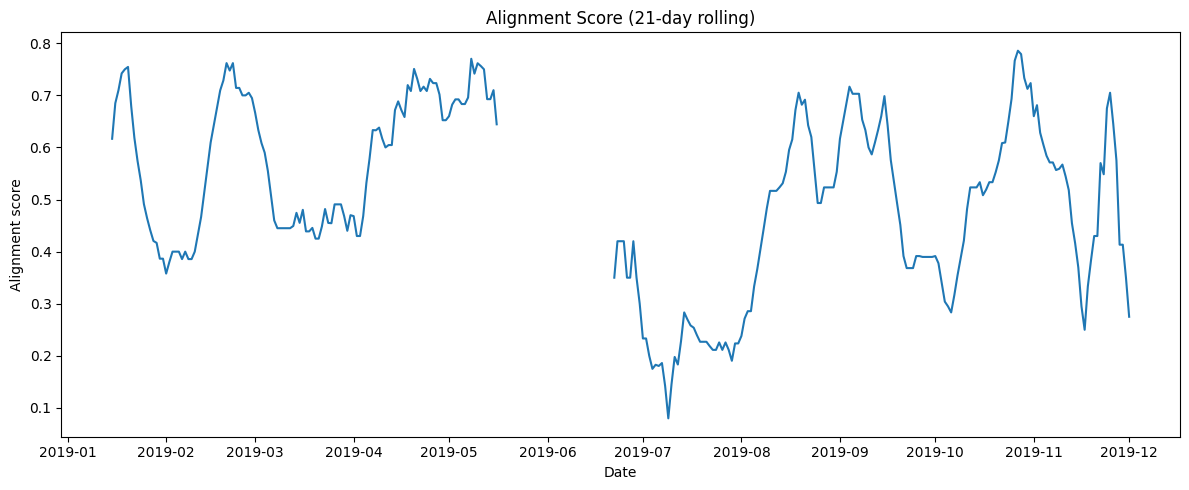

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(test["Date"], test[f"Alignment_Score_{CALIBRATION_WINDOW}"])
plt.title(f"Alignment Score ({CALIBRATION_WINDOW}-day rolling)")
plt.xlabel("Date")
plt.ylabel("Alignment score")
plt.tight_layout()
plt.show()

### 11. Compare rolling windows

Different rolling windows are tested to find the most useful balance between:

- responsiveness
- stability
- separation between high- and low-reliability periods

In [35]:
# Compare different rolling windows (7, 14, 21 days)
# to determine which alignment score best separates high- vs low-error periods

rows = []

for w in ROLLING_WINDOWS:
    # Select alignment score for this window
    score_col = f"Alignment_Score_{w}"
    tmp = test.copy()

    # Convert alignment score into LOW / MEDIUM / HIGH bands
    tmp["Band"] = pd.cut(
        tmp[score_col],
        bins=[-np.inf, 0.50, 0.65, np.inf],
        labels=["LOW", "MEDIUM", "HIGH"]
    )

    # Compute mean forecast error within each band
    grouped = tmp.groupby("Band", dropna=False)[
        ["AE_t7", "AE_t14", "AE_t21", "AE_t28"]
    ].mean()

    # Store results for comparison across windows
    for band in ["LOW", "MEDIUM", "HIGH"]:
        if band in grouped.index:
            rows.append({
                "Window": w,
                "Band": band,
                "AE_t7": grouped.loc[band, "AE_t7"],
                "AE_t14": grouped.loc[band, "AE_t14"],
                "AE_t21": grouped.loc[band, "AE_t21"],
                "AE_t28": grouped.loc[band, "AE_t28"],
            })

# Combine all results into a single table
window_compare = pd.DataFrame(rows)

print(window_compare)

   Window    Band     AE_t7    AE_t14    AE_t21    AE_t28
0       7     LOW  0.042626  0.050798  0.061064  0.062296
1       7  MEDIUM  0.037375  0.039613  0.057444  0.060107
2       7    HIGH  0.035822  0.041905  0.043384  0.047453
3      14     LOW  0.045442  0.058961  0.067252  0.074075
4      14  MEDIUM  0.039537  0.046196  0.066044  0.069341
5      14    HIGH  0.034901  0.041491  0.053607  0.050632
6      21     LOW  0.046398  0.059427  0.068268  0.067047
7      21  MEDIUM  0.037604  0.045986  0.060515  0.074001
8      21    HIGH  0.036033  0.042524  0.052166  0.050207


### 12. Export calibration table

In [36]:
calibration_output = test[[
    "Date",
    "Occupancy",
    "Guardrail",
    "Pred_t7", "Pred_t14", "Pred_t21", "Pred_t28",
    "target_t7", "target_t14", "target_t21", "target_t28",
    "Prob_Down_t1", "Prob_Up_t1", "Direction_Pred_t1",
    "Prob_Down_t7", "Prob_Up_t7", "Direction_Pred_t7",
    "Prob_Down_t14", "Prob_Up_t14", "Direction_Pred_t14",
    "Prob_Down_t21", "Prob_Up_t21", "Direction_Pred_t21",
    "Prob_Down_t28", "Prob_Up_t28", "Direction_Pred_t28",
    "Matured_T1_Correct",
    "Matured_T7_Correct",
    f"Recent_T1_Accuracy_{CALIBRATION_WINDOW}",
    f"Recent_T7_Accuracy_{CALIBRATION_WINDOW}",
    f"Alignment_Score_{CALIBRATION_WINDOW}",
    "Alignment_Band",
    "Strength_t7",
    "Strength_t14",
    "Strength_t21",
    "Strength_t28",
    "AE_t7", "AE_t14", "AE_t21", "AE_t28",
    "Calibrated_Action"
]].copy()

calibration_output.to_csv("operational_calibration_output.csv", index=False)

print("Saved: operational_calibration_output.csv")
print(calibration_output.head(20))

Saved: operational_calibration_output.csv
         Date  Occupancy  Guardrail   Pred_t7  Pred_t14  Pred_t21  Pred_t28  target_t7  target_t14  target_t21  target_t28  Prob_Down_t1  Prob_Up_t1  Direction_Pred_t1  Prob_Down_t7  Prob_Up_t7  Direction_Pred_t7  \
0  2019-01-01   0.557625          0  0.582151  0.672171  0.757092  0.799845   0.622225      0.7500      0.7125      0.6875      0.623047    0.376953                 -1      0.455473    0.544527                  0   
1  2019-01-02   0.569490          0  0.593610  0.678047  0.759999  0.797874   0.658123      0.7625      0.7000      0.6625      0.635127    0.364873                 -1      0.472617    0.527383                  0   
2  2019-01-03   0.569490          1  0.552710  0.622583  0.694791  0.742977   0.682055      0.7500      0.7000      0.6750      0.621443    0.378557                 -1      0.599575    0.400425                 -1   
3  2019-01-04   0.557625          0  0.566460  0.639264  0.707912  0.755500   0.694021      0.

In [37]:
# How often does each action fire?
test["Calibrated_Action"].value_counts(normalize=True).round(3)

Calibrated_Action
Monitor (low recent reliability)             0.461
Monitor (unstable)                           0.232
Maintain current settings                    0.125
Reduce pricing / push demand                 0.098
Increase pricing (strategic)                 0.036
Strong demand increase → act aggressively    0.021
Prepare for demand increase                  0.009
Increase pricing / reduce availability       0.006
Prepare promotions                           0.006
Adjust pricing upward (tactical)             0.003
Strong demand drop → act aggressively        0.003
Name: proportion, dtype: float64

In [38]:
# Does LOW alignment actually correspond to higher error?
test.groupby("Alignment_Band")[["AE_t7", "AE_t14", "AE_t21", "AE_t28"]].mean().round(4)

,AE_t7,AE_t14,AE_t21,AE_t28
Alignment_Band,,,,
HIGH,0.0361,0.0423,0.0530,0.0514
LOW,0.0464,0.0594,0.0683,0.0670
MEDIUM,0.0376,0.0464,0.0599,0.0734
UNKNOWN,0.0485,0.0865,0.0972,0.1134


### 13. Final Calibration Results

The calibration process confirms that combining forecast outputs with a reliability signal improves the operational layer.

#### Key findings

The **alignment score** is informative. Periods with high alignment generally show lower forecast errors across horizons, while low- and especially unknown-alignment periods are less reliable. For example, at T+28:

- HIGH alignment: lowest error
- LOW alignment: higher error
- UNKNOWN: highest error

This confirms that recent realized model performance is a useful proxy for current reliability.


The **guardrail and alignment** provide complementary signals

- The guardrail captures structural instability
- The alignment score captures recent forecasting quality

Using both together improves decision robustness compared with using either layer alone.


The **calibrated action mix** is more realistic

The calibrated system produces mostly monitoring or conservative actions, while strong actions become relatively rare.

This is more consistent with real operational decision-making than the earlier rule set, which was too aggressive.


**Longer-horizon signals** should drive strong actions. Strong actions are now only triggered when:

- both T+21 and T+28 show strong directional signals
- recent alignment is high
- no instability is detected

This ensures that strong decisions are supported by both consistency and reliability.

#### Final design choices

- Alignment window: 21 days
- Alignment score:
  - 30% T+1 accuracy
  - 70% T+7 accuracy
- Alignment bands:
  - HIGH ≥ 0.65
  - MEDIUM 0.50–0.65
  - LOW < 0.50
- Aggressive actions allowed only under HIGH alignment


#### Conclusion

The calibrated operational layer successfully transforms model outputs into more reliable business actions.

It balances:

- predictive signals (direction and strength)
- recent realized model performance (alignment)
- structural instability (guardrail)

This makes the operational system more cautious, more interpretable, and better suited to real-world use.